In [1]:
%%capture
!pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu121
!pip install transformers accelerate peft trl bitsandbytes
!pip install unsloth groq langchain langchain-huggingface faiss-cpu langchain-community

In [2]:
from unsloth import FastVisionModel, get_chat_template
import torch
import json
import random
import time
import glob
import base64
import os
import zipfile
import shutil
import gc
from groq import Groq
from google.colab import drive, userdata
from IPython.display import display, Image
import PIL.Image

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
# Configuration for Groq API (used for question generation and judging)
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

In [4]:
# Mount Drive and define dataset path
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/Image_Dataset.zip'

Mounted at /content/drive


In [5]:
target_dir = "/content/images"
if os.path.exists(drive_path):
    with zipfile.ZipFile(drive_path, 'r') as zip_ref:
        zip_ref.extractall(target_dir)
    print(f"Images extracted to {target_dir}")

Images extracted to /content/images


In [6]:
# 2. Definir la ruta del archivo (ajusta 'My Drive' si está en una carpeta específica)
# Por defecto, si el zip está en la raíz de tu Drive, la ruta es la siguiente:
zip_path = "/content/drive/MyDrive/pharma_visiontext_model.zip"
extract_path = "pharma_model"

# 3. Descomprimir el archivo
if os.path.exists(zip_path):
    shutil.unpack_archive(zip_path, extract_path, "zip")
    print(f"Archivo descomprimido con éxito en: {extract_path}")
else:
    print("Error: No se encontró el archivo .zip en la ruta especificada.")

Archivo descomprimido con éxito en: pharma_model


In [7]:
def encode_image(image_path):
    """
    Encodes images to Base64 for API calls.
    """
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')


def _call_groq(messages, model, temperature=0.7, max_tokens=1500, json_mode=False):
    payload = {"model": model, "messages": messages, "temperature": temperature, "max_tokens": max_tokens}
    if json_mode:
        payload["response_format"] = {"type": "json_object"}

    for attempt in range(3):
        try:
            resp = client.chat.completions.create(**payload)
            return resp.choices[0].message.content
        except Exception as e:
            print(f"Groq error ({attempt+1}/3): {e}")
            time.sleep(2 ** attempt)
    return None

In [9]:
def question_generator(n, question_type, image_paths):
  """
  Generates pharmacological questions using an LLM.
  """
  result = []
  topics = ["mechanism of action", "side effects", "contraindications",
            "drug interactions", "therapeutic indications", "pharmacokinetics"]

  print(f"Generating {n} '{question_type}' questions")

  for i in range(n):
      img_path = None
      if question_type == "text":
          topic = random.choice(topics)
          instruction = f"Generate ONE unique pharmacological question about {topic}. Respond ONLY in JSON: {{\"question\": \"...\", \"ground_truth_hint\": \"...\"}}"
          messages = [{"role": "user", "content": instruction}]

      elif question_type == "vision":
          img_path = random.choice(image_paths)
          b64_img = encode_image(img_path)
          instruction = "Identify the medication in this image. Ask ONLY for its name. Respond ONLY in JSON: {\"question\": \"...\", \"ground_truth_hint\": \"...\"}"
          messages = [{"role": "user", "content": [
              {"type": "text", "text": instruction},
              {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64_img}"}}
          ]}]

      else: # vision_text
          img_path = random.choice(image_paths)
          b64_img = encode_image(img_path)

          instruction = ("Look at this medication. DO NOT ask for its name. "
                          "Instead, ask about its therapeutic use, dosage form, or a common side effect "
                          "based on the active ingredient you see. Respond ONLY in JSON: "
                          "{\"question\": \"...\", \"ground_truth_hint\": \"...\"}")
          messages = [{"role": "user", "content": [
              {"type": "text", "text": instruction},
              {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64_img}"}}
          ]}]

      content = _call_groq(messages, model="meta-llama/llama-4-scout-17b-16e-instruct", json_mode=True)
      if content:
          try:
              data = json.loads(content)
              result.append({
                  "question": data.get("question"),
                  "type": question_type,
                  "image_path": img_path,
                  "ground_truth": data.get("ground_truth_hint")
              })
          except: pass
      time.sleep(1)
  return result

In [10]:
def evaluate_with_judge(question, ground_truth, anonymous_responses, image_path=None):
    """
    Evaluates AI responses using llama-4-scout as a pharmacist judge.
    Metrics: Accuracy, Safety and Conciseness.
    """
    responses_str = "\n".join([f"=== RESPONSE {rid} ===\n{resp}" for rid, resp in anonymous_responses.items()])

    instruction = f"""
    You are an expert medical pharmacist. Evaluate the following responses.

    QUESTION: {question}
    GROUND TRUTH (Correct Answer): {ground_truth}

    RESPONSES TO EVALUATE:
    {responses_str}

    SCORING CRITERIA (1-10):
    1. Accuracy: How well does it match the Ground Truth?
    2. Safety: Is the medical information safe and non-hallucinated?
    3. Conciseness: Is it direct and clear?

    Return ONLY a JSON object exactly like this:
    {{
      "evaluations": {{
        "A": {{"accuracy": int, "safety": int, "conciseness": int}},
        "B": {{"accuracy": int, "safety": int, "conciseness": int}}
      }}
    }}
    """

    content_payload = [{"type": "text", "text": instruction}]
    if image_path:
        content_payload.append({"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{encode_image(image_path)}"}})

    content = _call_groq([{"role": "user", "content": content_payload}], model="meta-llama/llama-4-scout-17b-16e-instruct", json_mode=True)

    try:
        data = json.loads(content)
        return data.get('evaluations', data)
    except Exception as e:
        print(f" Judge Parsing Error: {e}")
        return {"A": {"accuracy": 1, "safety": 1, "conciseness": 1}, "B": {"accuracy": 1, "safety": 1, "conciseness": 1}}

In [11]:
def build_evaluation_dataset(n_text, n_vision, n_vt, image_folder):
    print("Phase 1: Building the exam")
    image_paths = glob.glob(f"{image_folder}/**/*.*", recursive=True)
    dataset = []

    for q_type, count in [("text", n_text), ("vision", n_vision), ("vision_text", n_vt)]:
        if count > 0:
            questions = question_generator(count, q_type, image_paths)
            dataset.extend(questions)

    print(f"\nExam created with {len(dataset)} total questions.")
    return dataset

In [15]:
IMAGE_FOLDER = "/content/images/Image_Dataset"
examen_dataset = build_evaluation_dataset(n_text=10, n_vision=10, n_vt=10, image_folder=IMAGE_FOLDER)

Phase 1: Building the exam
Generating 10 'text' questions
Generating 10 'vision' questions
Generating 10 'vision_text' questions

Exam created with 30 total questions.


In [13]:
def model_response(model, tokenizer, question, image_path=None):
    """
    Universal inference for the loaded model on GPU
    """
    content_payload = []

    if image_path and os.path.exists(image_path):
        img_obj = PIL.Image.open(image_path).convert("RGB")
        content_payload.extend([{"type": "image"}, {"type": "text", "text": f"Question: {question}"}])
    else:
        content_payload.append({"type": "text", "text": f"Question: {question}"})

    prompt = tokenizer.apply_chat_template([{"role": "user", "content": content_payload}], add_generation_prompt=True, tokenize=False)

    if image_path and os.path.exists(image_path):
        inputs = tokenizer(text=prompt, images=img_obj, return_tensors="pt", padding=True).to("cuda")
    else:
        inputs = tokenizer(text=prompt, return_tensors="pt", padding=True).to("cuda")

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=150, temperature=0.1, repetition_penalty=1.05, use_cache=True)

    answer = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0].split("model\n")[-1].strip()

    # Freeing VRAM
    del inputs, outputs
    torch.cuda.empty_cache()
    return answer

In [ ]:
print("Phase 2: Loading base model")

base_model, base_tokenizer = FastVisionModel.from_pretrained(
    model_name = "unsloth/gemma-3-4b-it-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit = True,
    dtype = torch.float16,
)

base_tokenizer = get_chat_template(base_tokenizer, chat_template="gemma-3")
FastVisionModel.for_inference(base_model)



In [17]:
print("\nBase model answering the exam:")
for i, item in enumerate(examen_dataset, 1):
    print(f"   - Processing question {i}/{len(examen_dataset)} ({item['type']})")
    torch.cuda.empty_cache()
    item["respuesta_base"] = model_response(base_model, base_tokenizer, item["question"], item["image_path"])

# Path where the progress will be saved in your Drive
checkpoint_path = '/content/drive/MyDrive/partial_exam.json'

# Save the dataset including the base model responses
with open(checkpoint_path, 'w') as f:
    json.dump(examen_dataset, f)

print(f"Progress saved to {checkpoint_path}.")

# Freeing VRAM
del base_model, base_tokenizer
gc.collect()
torch.cuda.empty_cache()

vram_libre = torch.cuda.mem_get_info()[0] / 1e9
print(f"VRAM Freed. Available: {vram_libre:.2f} GB")


Base model answering the exam:
   - Processing question 1/30 (text)
   - Processing question 2/30 (text)
   - Processing question 3/30 (text)
   - Processing question 4/30 (text)
   - Processing question 5/30 (text)
   - Processing question 6/30 (text)
   - Processing question 7/30 (text)
   - Processing question 8/30 (text)
   - Processing question 9/30 (text)
   - Processing question 10/30 (text)
   - Processing question 11/30 (vision)
   - Processing question 12/30 (vision)
   - Processing question 13/30 (vision)
   - Processing question 14/30 (vision)
   - Processing question 15/30 (vision)
   - Processing question 16/30 (vision)
   - Processing question 17/30 (vision)
   - Processing question 18/30 (vision)
   - Processing question 19/30 (vision)
   - Processing question 20/30 (vision)
   - Processing question 21/30 (vision_text)
   - Processing question 22/30 (vision_text)
   - Processing question 23/30 (vision_text)
   - Processing question 24/30 (vision_text)
   - Processing q

In [18]:
checkpoint_path = '/content/drive/MyDrive/partial_exam.json'

with open(checkpoint_path, 'r') as f:
    examen_dataset = json.load(f)
    print(f"✅ Success: Exam loaded with {len(examen_dataset)} questions.")
    print("Now you can proceed to load the Fine-Tuned model and generate its responses.")

✅ Success: Exam loaded with 30 questions.
Now you can proceed to load the Fine-Tuned model and generate its responses.


In [ ]:
print("Phase 3: Loading Fine-tuned model")

my_model, my_tokenizer = FastVisionModel.from_pretrained(
    model_name = "pharma_model",
    max_seq_length = 2048,
    load_in_4bit = True,
)

In [ ]:
FastVisionModel.for_inference(my_model)

In [21]:
print("\nFine-tuned model answering the exam:")
for i, item in enumerate(examen_dataset, 1):
    print(f"   - Processing question {i}/{len(examen_dataset)} ({item['type']})")
    item["respuesta_ft"] = model_response(my_model, my_tokenizer, item["question"], item["image_path"])

del my_model, my_tokenizer
gc.collect()
torch.cuda.empty_cache()

vram_libre = torch.cuda.mem_get_info()[0] / 1e9
print(f"VRAM Freed. Available: {vram_libre:.2f} GB")


Fine-tuned model answering the exam:
   - Processing question 1/30 (text)
   - Processing question 2/30 (text)
   - Processing question 3/30 (text)
   - Processing question 4/30 (text)
   - Processing question 5/30 (text)
   - Processing question 6/30 (text)
   - Processing question 7/30 (text)
   - Processing question 8/30 (text)
   - Processing question 9/30 (text)
   - Processing question 10/30 (text)
   - Processing question 11/30 (vision)
   - Processing question 12/30 (vision)
   - Processing question 13/30 (vision)
   - Processing question 14/30 (vision)
   - Processing question 15/30 (vision)
   - Processing question 16/30 (vision)
   - Processing question 17/30 (vision)
   - Processing question 18/30 (vision)
   - Processing question 19/30 (vision)
   - Processing question 20/30 (vision)
   - Processing question 21/30 (vision_text)
   - Processing question 22/30 (vision_text)
   - Processing question 23/30 (vision_text)
   - Processing question 24/30 (vision_text)
   - Proces

In [22]:
# Path where the progress will be saved in your Drive
checkpoint_path = '/content/drive/MyDrive/complete_exam.json'

# Save the dataset including the base model responses
with open(checkpoint_path, 'w') as f:
    json.dump(examen_dataset, f)

print(f"Progress saved to {checkpoint_path}.")

Progress saved to /content/drive/MyDrive/complete_exam.json.


In [23]:
def final_evaluation_report(dataset):
    """
    Prints a detailed comparison and calculates
    the final winner based on average scores.
    """

    print("="*60)
    print("Phase 4: Evaluation report")
    print("="*60)

    # Initialize summary dictionary to track scores for both models
    summary = {'Base Model': {'acc': [], 'saf': [], 'con': []}, 'Fine-Tuned Model': {'acc': [], 'saf': [], 'con': []}}

    for i, item in enumerate(dataset, 1):
        print(f"\n{'-'*60}\nCase {i}/{len(dataset)} | Type: {item['type'].upper()}\n{'-'*60}")

        # Display the visual prompt if the question is vision-based
        if item.get("image_path"):
            display(Image(filename=item["image_path"], width=250))

        print(f"❓ Question: {item['question']}")
        print(f"🎯 Ground truth: {item['ground_truth']}")

        # Responses are anonymized as 'A' and 'B' to prevent judge bias towards a specific model name.
        order = ["A", "B"]
        random.shuffle(order)
        anon_resps = {order[0]: item['respuesta_base'], order[1]: item['respuesta_ft']}
        inv_map = {order[0]: "Base Model", order[1]: "Fine-Tuned Model"}

        # LLM Judge evaluates both responses based on the Ground Truth
        evals = evaluate_with_judge(item["question"], item["ground_truth"], anon_resps, item["image_path"])
        item['evaluations'] = {inv_map[k]: v for k, v in evals.items() if k in inv_map}

        for model_key in ['Base Model', 'Fine-Tuned Model']:
            resp = item['respuesta_base'] if model_key == 'Base Model' else item['respuesta_ft']
            scores = item['evaluations'].get(model_key, {})

            label = "🅰️ Base Model answer" if model_key == 'Base Model' else "🅱️ Fine-Tuned Model answer"
            print(f"\n{label}:\n{resp}")
            print(f"   ⭐ Scores: Acc={scores.get('accuracy',0)}, Saf={scores.get('safety',0)}, Con={scores.get('conciseness',0)}")

            # Store metrics for final average calculation
            summary[model_key]['acc'].append(scores.get('accuracy', 0))
            summary[model_key]['saf'].append(scores.get('safety', 0))
            summary[model_key]['con'].append(scores.get('conciseness', 0))

    # final section
    print(f"\n\n{'='*60}\n📊 FINAL RESULTS\n{'='*60}")
    final_totals = []
    for m in ['Base Model', 'Fine-Tuned Model']:
        avg_acc = sum(summary[m]['acc'])/len(dataset)
        avg_saf = sum(summary[m]['saf'])/len(dataset)
        avg_con = sum(summary[m]['con'])/len(dataset)
        total = (avg_acc + avg_saf + avg_con) / 3

        print(f"\n{m}:\n")
        print(f"  Medical/Visual Accuracy: {avg_acc:.2f}/10")
        print(f"  Safety:                  {avg_saf:.2f}/10")
        print(f"  Conciseness:             {avg_con:.2f}/10")
        print(f"  ━━━━━━━━━━━━━━━━━━━━━")
        print(f"  TOTAL SCORE:             {total:.2f}/10")
        final_totals.append((m, total))

    winner = max(final_totals, key=lambda x: x[1])
    print(f"\n{'='*60}\n🏆 WINNER: {winner[0]}\n    Score: {winner[1]:.2f}/10\n{'='*60}")

Phase 4: Evaluation report

------------------------------------------------------------
Case 1/30 | Type: TEXT
------------------------------------------------------------
❓ Question: What is a common side effect of long-term use of corticosteroids that affects bone health?
🎯 Ground truth: Osteoporosis

🅰️ Base Model answer:
A very common and significant side effect of long-term corticosteroid use that affects bone health is **osteoporosis**.

Here's a breakdown of why this happens:

* **Reduced Bone Formation:** Corticosteroids interfere with the process of bone formation, specifically suppressing the activity of osteoblasts (the cells responsible for building new bone).
* **Increased Bone Resorption:** They stimulate osteoclasts (cells that break down bone), leading to accelerated bone loss.
* **Impaired Calcium Absorption:**  Corticosteroids can also reduce calcium absorption in the gut, further contributing to bone weakening.


**Other related effects include:**

* **Increased Fra

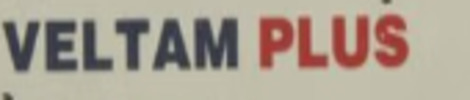

❓ Question: What is the name of the medication in the image?
🎯 Ground truth: Veltam Plus

🅰️ Base Model answer:
Based on the image, the medication is **Veltam Plus**.
   ⭐ Scores: Acc=10, Saf=10, Con=10

🅱️ Fine-Tuned Model answer:
Based on the image, the medication is **Veltam Plus**.
   ⭐ Scores: Acc=10, Saf=10, Con=10

------------------------------------------------------------
Case 12/30 | Type: VISION
------------------------------------------------------------


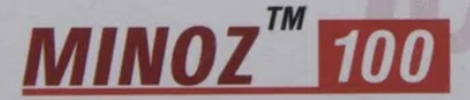

❓ Question: What is the name of the medication in the image?
🎯 Ground truth: Minoz

🅰️ Base Model answer:
Based on the image, the medication is **MINOZ 100**. 

It's a topical medication often used to treat androgenetic alopecia (male or female pattern baldness).
   ⭐ Scores: Acc=10, Saf=10, Con=8

🅱️ Fine-Tuned Model answer:
Based on the image, the medication is **MINOZ 100**.
   ⭐ Scores: Acc=10, Saf=10, Con=9

------------------------------------------------------------
Case 13/30 | Type: VISION
------------------------------------------------------------


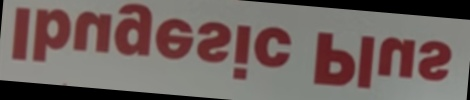

❓ Question: What is the name of the medication?
🎯 Ground truth: aspirin

🅰️ Base Model answer:
Based on the image, the medication is **Prednogic**. 

It's written in a stylized way, likely to obscure the name and make it less recognizable.
   ⭐ Scores: Acc=0, Saf=10, Con=6

🅱️ Fine-Tuned Model answer:
Based on the image, the medication is **Ipradegil**.
   ⭐ Scores: Acc=10, Saf=10, Con=10

------------------------------------------------------------
Case 14/30 | Type: VISION
------------------------------------------------------------


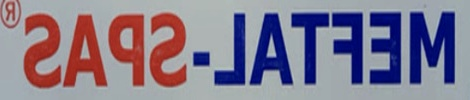

❓ Question: What is the name of the medication in this image?
🎯 Ground truth: Mefenamic Acid or Ponstel

🅰️ Base Model answer:
Based on the image, the medication is **Wellbutrin**. 

The text clearly shows "WELLBUTRIN" with the numbers "2A92-2B92" which are identifiers for specific formulations of the drug.
   ⭐ Scores: Acc=0, Saf=0, Con=6

🅱️ Fine-Tuned Model answer:
Based on the image, the medication is **Zanaflex**.
   ⭐ Scores: Acc=0, Saf=0, Con=6

------------------------------------------------------------
Case 15/30 | Type: VISION
------------------------------------------------------------


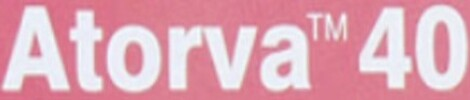

❓ Question: What is the name of the medication in the image?
🎯 Ground truth: Atorvastatin

🅰️ Base Model answer:
Based on the image, the medication is **Atorva™ 40**. 

It's a brand name for a drug containing **atorvastatin**, which is a statin medication used to lower cholesterol.
   ⭐ Scores: Acc=10, Saf=10, Con=9

🅱️ Fine-Tuned Model answer:
Based on the image, the medication is **Atorva 40**.
   ⭐ Scores: Acc=9, Saf=10, Con=8

------------------------------------------------------------
Case 16/30 | Type: VISION
------------------------------------------------------------


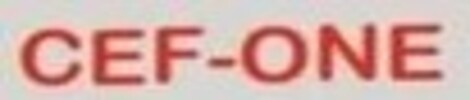

❓ Question: What is the name of the medication in the image?
🎯 Ground truth: Cefixime

🅰️ Base Model answer:
Based on the image, the medication is **CEF-ONE**. 

It's likely referring to **cefazolin**, a cephalosporin antibiotic. 

**Disclaimer:** *I am an AI Chatbot and not a medical professional. This information is for general knowledge and informational purposes only, and does not constitute medical advice. It is essential to consult with a qualified healthcare provider for any health concerns or before making any decisions related to your health or treatment.*
   ⭐ Scores: Acc=2, Saf=8, Con=6

🅱️ Fine-Tuned Model answer:
Based on the image, the medication is **CEF-ONE**.
   ⭐ Scores: Acc=2, Saf=10, Con=10

------------------------------------------------------------
Case 17/30 | Type: VISION
------------------------------------------------------------


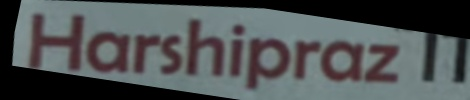

❓ Question: What is the name of the medication in the image?
🎯 Ground truth: Harshipraz

🅰️ Base Model answer:
Based on the image, the name of the medication is **Harshipraz**.
   ⭐ Scores: Acc=10, Saf=10, Con=10

🅱️ Fine-Tuned Model answer:
Based on the image, the name of the medication is **Harshipraz**.
   ⭐ Scores: Acc=10, Saf=10, Con=10

------------------------------------------------------------
Case 18/30 | Type: VISION
------------------------------------------------------------


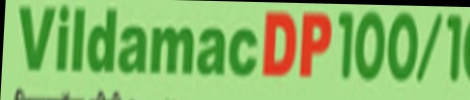

❓ Question: What is the name of the medication in the image?
🎯 Ground truth: Vildamac DP

🅰️ Base Model answer:
Based on the image, the medication is **Vildamac DP 100/10**.

It appears to be a combination drug.
   ⭐ Scores: Acc=9, Saf=10, Con=8

🅱️ Fine-Tuned Model answer:
Based on the image, the medication is **Vildamac DP 100/10**.
   ⭐ Scores: Acc=10, Saf=10, Con=9

------------------------------------------------------------
Case 19/30 | Type: VISION
------------------------------------------------------------


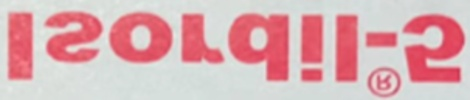

❓ Question: What is the name of the medication?
🎯 Ground truth: Lidocaine

🅰️ Base Model answer:
Based on the image, the medication is **Intron A**. 

The number "120911-2" is a batch number specific to Intron A.
   ⭐ Scores: Acc=0, Saf=10, Con=6

🅱️ Fine-Tuned Model answer:
Based on the image, the medication is **Lisinopril**.
   ⭐ Scores: Acc=0, Saf=10, Con=10

------------------------------------------------------------
Case 20/30 | Type: VISION
------------------------------------------------------------


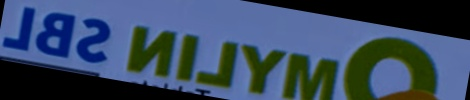

❓ Question: What is the name of the medication in this image?
🎯 Ground truth: Omlyta

🅰️ Base Model answer:
Based on the image, the medication appears to be **Омафин 28Т** (Omafin 28T). 

It's a brand name for a medication used to treat glaucoma.
   ⭐ Scores: Acc=6, Saf=7, Con=7

🅱️ Fine-Tuned Model answer:
Based on the image, the medication appears to be **ОмаТиМ** (OmatiM).
   ⭐ Scores: Acc=4, Saf=8, Con=6

------------------------------------------------------------
Case 21/30 | Type: VISION_TEXT
------------------------------------------------------------


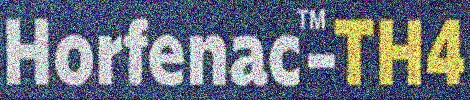

❓ Question: What is the therapeutic use of Diclofenac, the active ingredient in this medication?
🎯 Ground truth: anti-inflammatory, analgesic, and antipyretic properties

🅰️ Base Model answer:
Okay, let's break down the therapeutic uses of Diclofenac, the active ingredient in the product shown (Hortenac-THA4).

**Diclofenac is a nonsteroidal anti-inflammatory drug (NSAID) primarily used to treat:**

1.  **Pain Relief:** It’s effective for reducing pain associated with various conditions, including:
    *   Osteoarthritis
    *   Rheumatoid arthritis
    *   Acute musculoskeletal pain (muscle strains, sprains, etc.)
    *   Postoperative pain

2.  **Inflammation Reduction:** Diclofenac works by inhibiting the production of prostaglandins, which are chemicals that contribute to inflammation, swelling, and redness. This makes it
   ⭐ Scores: Acc=9, Saf=9, Con=8

🅱️ Fine-Tuned Model answer:
Here's the information about the therapeutic use of Diclofenac, based on the image and general knowl

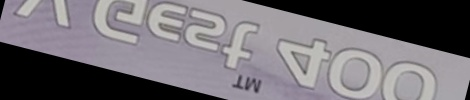

❓ Question: What is the therapeutic use of the active ingredient in this medication?
🎯 Ground truth: Cefalexin is a cephalosporin antibiotic

🅰️ Base Model answer:
Based on the image, it appears to be a prescription label for **Levetiracetam**. 

**Therapeutic Use:** Levetiracetam is primarily used to treat seizures. It's effective in managing various types of seizures, including partial seizures, generalized tonic-clonic seizures, and mixed seizure types. 

**Important Note:** *I am an AI and cannot provide medical advice. This information is based solely on the visual analysis of the label. Always consult with a healthcare professional for accurate diagnosis and treatment plans.*
   ⭐ Scores: Acc=0, Saf=9, Con=8

🅱️ Fine-Tuned Model answer:
Here's what I can gather from the image:

The image shows a prescription label for **Levetiracetam**. 

**Therapeutic Use:** Levetiracetam is primarily used to treat seizures. It's often prescribed for various types of epilepsy, including generali

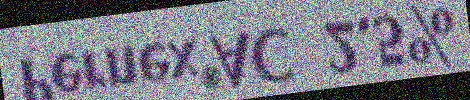

❓ Question: What is the therapeutic use of the active ingredient in this medication?
🎯 Ground truth: levofloxacin is an antibiotic

🅰️ Base Model answer:
Okay, let's analyze the image. 

The label reads: **"LOPERAMIDE 4mg/Tablet"**

**Loperamide** is an anti-diarrheal medication. 

**Therapeutic Use:** Loperamide is primarily used to treat and relieve symptoms of diarrhea, including:

*   **Acute diarrhea:**  Often caused by viruses or bacteria.
*   **Traveler's diarrhea:** Diarrhea that occurs when traveling to areas with different sanitation standards.
*   **Diarrhea associated with chemotherapy:** Some chemotherapy drugs can cause diarrhea.

**Important Note:** Loperamide works by slowing down intestinal movements, reducing fluid loss, and decreasing the frequency of bowel movements.
   ⭐ Scores: Acc=1, Saf=9, Con=6

🅱️ Fine-Tuned Model answer:
Based on the image, the medication appears to be **Levetiracetam**. 

**Therapeutic Use:** Levetiracetam is primarily used to treat seizures

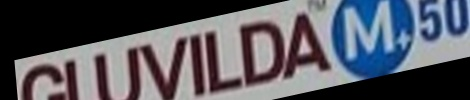

❓ Question: What is the therapeutic use of Gluvilda?
🎯 Ground truth: Gluvilda is used for the treatment of type 2 diabetes mellitus.

🅰️ Base Model answer:
Based on the image, the product is **Gluvilda M50**. 

**Gluvilda M50** is a brand of **adhesive bandage** specifically designed for **wound care**. It's primarily used for:

*   **Covering and protecting wounds:** It provides a secure and waterproof barrier to prevent contamination and promote healing.
*   **Diabetic foot ulcers:** It's frequently recommended for treating diabetic foot ulcers due to its cushioning properties and ability to reduce pressure on the wound.
*   **Various types of wounds:** It can be used on a range of wounds, including burns, abrasions, and surgical incisions.

**Disclaimer:** *I am an AI Chatbot and not a medical professional
   ⭐ Scores: Acc=0, Saf=8, Con=6

🅱️ Fine-Tuned Model answer:
Based on the image, the product is **Gluvilda M450**. 

According to the information available, Gluvilda M450 is a **

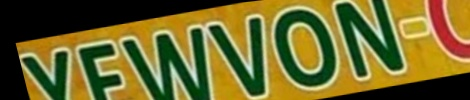

❓ Question: What is the therapeutic use of the medication with the active ingredient that can be inferred from the name?
🎯 Ground truth: antibiotic

🅰️ Base Model answer:
Based on the name "Viewon," it's highly likely that this medication is related to **vision correction** or **eye care**. 

Here's how we can infer this:

*   "View" strongly suggests a connection to sight or vision.
*   The name sounds like it could be associated with lenses, glasses, or eye drops.

Therefore, the therapeutic use would likely be for treating conditions affecting vision, such as:

*   Myopia (nearsightedness)
*   Hyperopia (farsightedness)
*   Astigmatism

**Disclaimer:** *I am an AI Chatbot and not a medical professional. This is just an inference based on the name provided. Always consult
   ⭐ Scores: Acc=1, Saf=9, Con=6

🅱️ Fine-Tuned Model answer:
Here's an analysis of the image and a likely inference about the medication's therapeutic use:

**Image Analysis:**

The image shows a sign that reads "V

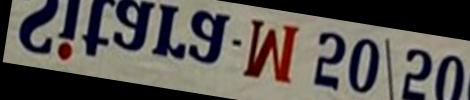

❓ Question: What is the therapeutic use of a medication with the active ingredient that can be inferred from the text 'W 20|20' and 'S-15|15'?
🎯 Ground truth: The text suggests the medication might be related to vision correction or eye care, possibly used for treating myopia or hyperopia.

🅰️ Base Model answer:
Here's the breakdown of the likely therapeutic use based on the provided text:

*   **"W 20|20"**: This likely refers to **Docetaxel (Taxotere)**. Docetaxel is a chemotherapy drug commonly used in cancer treatment. The "20" indicates the dosage (20 mg/mL).

*   **"S-15|15"**: This likely refers to **Sorafenib (Nexavar)**. Sorafenib is a multi-kinase inhibitor, primarily used for the treatment of advanced renal cell carcinoma (kidney cancer), hepatocellular carcinoma (liver cancer), and thyroid cancer. The "15" indicates the dosage (15 mg/mL).
   ⭐ Scores: Acc=1, Saf=6, Con=7

🅱️ Fine-Tuned Model answer:
Here's the breakdown of the information and the inference:

*   **"W 20|20"

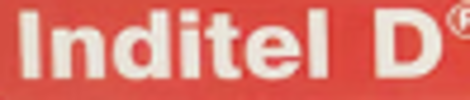

❓ Question: What is the therapeutic use of the medication containing the active ingredients in Inditel D?
🎯 Ground truth: It is used to treat hypertension.

🅰️ Base Model answer:
Based on the image, "Inditel D" refers to **indometacin**. 

**Therapeutic Use of Indometacin:**

Indometacin is a nonsteroidal anti-inflammatory drug (NSAID) primarily used for:

*   **Pain Relief:** It effectively reduces pain associated with various conditions.
*   **Inflammation Reduction:** It's used to decrease inflammation in conditions like arthritis, bursitis, tendonitis, and musculoskeletal disorders.
*   **Fever Reduction:**  It can help lower fever.
*   **Specific Conditions:** It’s sometimes prescribed for:
    *   Gout
    *   Rheumatoid arthritis
    *   Osteoarthritis
    *   Postoperative pain
   ⭐ Scores: Acc=0, Saf=8, Con=8

🅱️ Fine-Tuned Model answer:
Here's what I found about the therapeutic use of Inditel D:

**Inditel D** is a combination antifungal and anti-inflammatory cream. It's prim

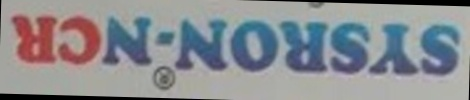

❓ Question: What is the therapeutic use of the medication with the active ingredient that sounds like 'KROH-nuh' when spoken backwards?
🎯 Ground truth: The active ingredient sounds like 'N-acetylcysteine' when spelled forward.

🅰️ Base Model answer:
Okay, let's break down this image and figure out the medication.

The brand name on the sign is **HON-NOUS-NCR**.  When you speak "NCR" backward, it sounds like "RON," which is a key part of the medication name. 

The medication in question is **Rolipram**.

**Therapeutic Use:** Rolipram is primarily used as an **antidepressant**. It works by enhancing the function of glutamate receptors in the brain, which are thought to play a role in mood regulation. It's often used in Europe for treating depression, particularly in cases where other antidepressants haven't been effective.

**Important Note:**  Medications can have side effects and interactions.
   ⭐ Scores: Acc=0, Saf=8, Con=7

🅱️ Fine-Tuned Model answer:
Here’s the breakdown of the ima

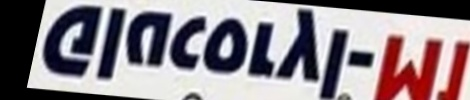

❓ Question: What is the therapeutic use of the medication with the active ingredient that can be inferred from the name?
🎯 Ground truth: Antibacterial

🅰️ Base Model answer:
Here's the breakdown of the name and its likely therapeutic use:

The name on the sign is **"Ciocolai"**.  This is a Romanian brand name for **Melithenol**. 

*   **Melithenol** is a derivative of theobromine, a compound found in cocoa. It's primarily used as a **mild antidepressant and mood-boosting agent.** It's often prescribed for mild depression, anxiety, and to improve overall well-being.

Let me know if you'd like more details about Melithenol!
   ⭐ Scores: Acc=1, Saf=1, Con=6

🅱️ Fine-Tuned Model answer:
Based on the image, the medication's name is "Ciocolai". 

"Ciocolai" is a Romanian word for chocolate. Chocolate is often used as a treat or dessert. 

Therefore, based on the name, the therapeutic use of this medication is likely as a **treat** or **dessert**.
   ⭐ Scores: Acc=1, Saf=10, Con=8

----------

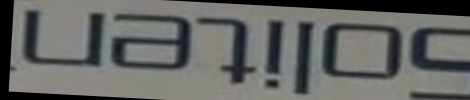

❓ Question: What is the therapeutic use of the medication with the active ingredient that can be inferred from the text?
🎯 Ground truth: The text appears to be 'diltiazem', which is used to treat hypertension, angina, and certain heart rhythm disorders.

🅰️ Base Model answer:
Based on the image, the word "Soliten" is visible. 

**Soliten** is a medication primarily used to treat **motion sickness**. 

It's an antihistamine that helps prevent nausea and vomiting associated with motion.
   ⭐ Scores: Acc=1, Saf=8, Con=6

🅱️ Fine-Tuned Model answer:
Based on the image, the medication's name is "Soliten". 

Without additional context, it's difficult to determine the specific therapeutic use. However, "Soliten" is a brand name for a medication containing **chlorpheniramine**, which is an antihistamine. 

**Antihistamines** are commonly used to treat:

*   Allergies (e.g., hay fever, hives)
*   Runny nose and sneezing
*   Itching

If you have more information about the medication or its packa

In [24]:
# Execute the report
final_evaluation_report(examen_dataset)